# k-নিকটতম প্রতিবেশী (KNN)**গল্প: তোমার 5 বন্ধুর মতো তুমি**কল্পনা করো তুমি নতুন একটি স্কুলে এসেছ। তুমি দেখলে তোমার সবচেয়ে কাছের 5 জন বন্ধু কী করছে। তারা যদি লাইনে দাঁড়ায়, তুমিও দাঁড়াবে। তারা যদি হাসে, তুমিও হাসবে।KNN (k-Nearest Neighbors) ঠিক এভাবেই কাজ করে! এটি একটি নতুন ডেটা পয়েন্ট দেখে তার সবচেয়ে কাছের kটি প্রতিবেশীর ভোট নেয় এবং সিদ্ধান্ত নেয়।

## আমরা কী শিখব?1. KNN ক্লাসিফায়ার ও রিগ্রেসর2. k-এর মান বড় বা ছোট হলে কী হয়3. সিদ্ধান্তের সীমানা (Decision Boundary) দেখা4. ট্রেন ও টেস্ট accuracy তুলনা করা

## প্রথমে লাইব্রেরি ইম্পোর্ট করি

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.datasets import load_iris, make_regression
from sklearn.model_selection import train_test_split
print('লাইব্রেরি ইম্পোর্ট সফল হয়েছে!')

লাইব্রেরি ইম্পোর্ট সফল হয়েছে!


## Iris ডেটাসেট চিনে নেওয়াIris একটি বিখ্যাত ফুলের ডেটাসেট। এখানে 3 রকমের ফুল আছে: Setosa, Versicolor, Virginica।প্রতিটি ফুলের 4টি বৈশিষ্ট্য (feature) আছে। KNN ব্যবহার করে আমরা একটি ফুলের বৈশিষ্ট্য দেখে বলব এটি কোন প্রজাতির!

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
print('ডেটার মোট নমুনা:', X.shape[0])
print('প্রতি ফুলের বৈশিষ্ট্য:', X.shape[1])
print('ফুলের প্রকার:', iris.target_names)
print('প্রথম 5টি ফুলের বৈশিষ্ট্য:')
print(X[:5])

ডেটার মোট নমুনা: 150
প্রতি ফুলের বৈশিষ্ট্য: 4
ফুলের প্রকার: ['setosa' 'versicolor' 'virginica']
প্রথম 5টি ফুলের বৈশিষ্ট্য:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


## ট্রেন ও টেস্ট সেটে ভাগ করাডেটাকে দুই ভাগে ভাগ করি: **ট্রেন সেট** (মডেল শেখার জন্য) এবং **টেস্ট সেট** (মডেল পরীক্ষার জন্য)।এটা পড়ার মতো - তুমি পড়াশোনা করে (ট্রেন) তারপর পরীক্ষা দাও (টেস্ট)!

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
print('ট্রেন সেটে নমুনা:', X_train.shape[0])
print('টেস্ট সেটে নমুনা:', X_test.shape[0])

ট্রেন সেটে নমুনা: 112
টেস্ট সেটে নমুনা: 38


## KNN মডেল তৈরি ও প্রশিক্ষণএখন KNN ক্লাসিফায়ার তৈরি করব। প্রথমে k=5 (5 জন বন্ধু) নিই।

In [4]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
train_score = knn.score(X_train, y_train)
test_score = knn.score(X_test, y_test)
print('ট্রেন সেটে নির্ভুলতা:', train_score)
print('টেস্ট সেটে নির্ভুলতা:', test_score)

ট্রেন সেটে নির্ভুলতা: 0.9642857142857143
টেস্ট সেটে নির্ভুলতা: 1.0


## k-এর মান বদলালে কী হয়?**ছোট k (যেমন k=1):** ট্রেন ডেটায় খুব ভালো, কিন্তু টেস্টে খারাপ (Overfitting)**বড় k (যেমন k=15):** মসৃণ সিদ্ধান্ত নেয়, কিন্তু সরল হয়ে যেতে পারে (Underfitting)নিচে k-এর বিভিন্ন মান দিয়ে accuracy তুলনা করি।

In [5]:
k_values = [1, 3, 5, 10, 15]
print('{:>3}  {:>7}  {:>7}'.format('k', 'Train', 'Test'))
print('-' * 20)
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc = knn.score(X_train, y_train)
    test_acc = knn.score(X_test, y_test)
    print('{:>3}  {:>7.3f}  {:>7.3f}'.format(k, train_acc, test_acc))

  k    Train     Test
--------------------
  1    1.000    1.000
  3    0.946    1.000
  5    0.964    1.000
 10    0.964    1.000
 15    0.973    1.000


## k-এর মান বনাম accuracy গ্রাফ

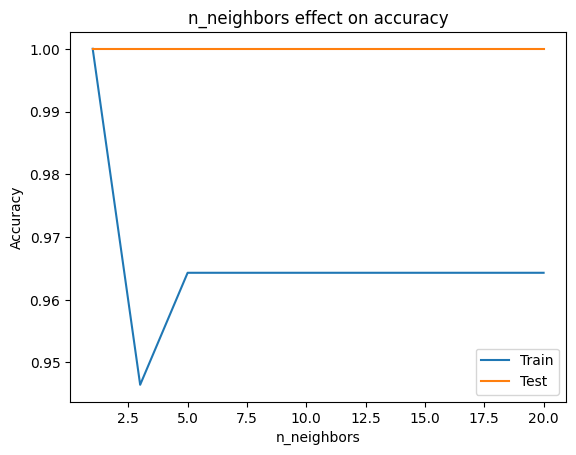

In [6]:
neighbors = [1, 3, 5, 10, 20]
train_scores = []
test_scores = []
for n in neighbors:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))
plt.plot(neighbors, train_scores, label='Train')
plt.plot(neighbors, test_scores, label='Test')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.legend()
plt.title('n_neighbors effect on accuracy')
plt.show()

## সিদ্ধান্তের সীমানা (Decision Boundary)KNN কীভাবে সিদ্ধান্ত নেয় তা বোঝার জন্য 2টি বৈশিষ্ট্য দিয়ে চিত্র আঁকি। বিভিন্ন k-এর জন্য সীমানা কেমন পরিবর্তন হয় তা দেখো।

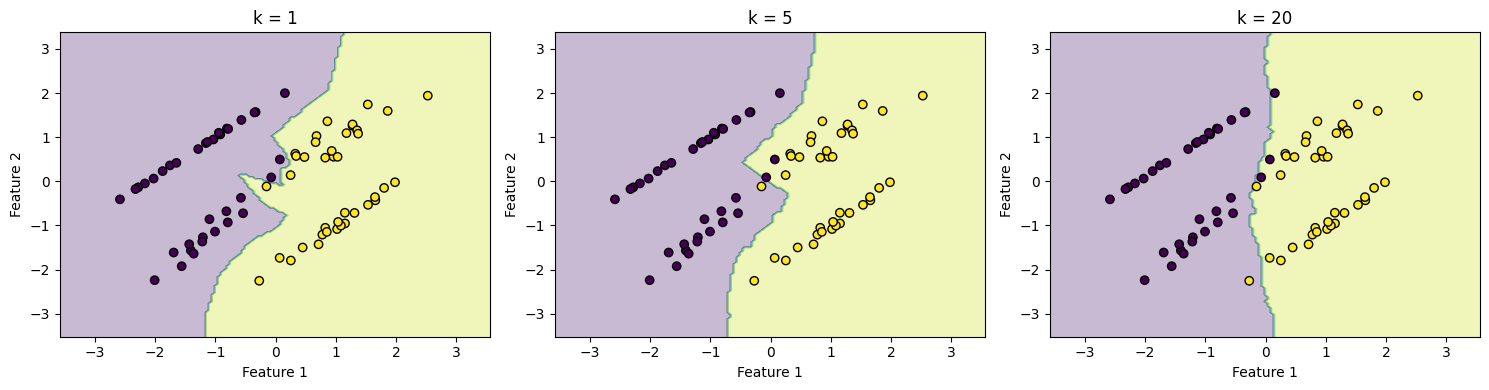

In [7]:
from sklearn.datasets import make_classification
X2, y2 = make_classification(n_features=2, n_redundant=0,
                             n_informative=2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, k in enumerate([1, 5, 20]):
    knn2 = KNeighborsClassifier(n_neighbors=k)
    knn2.fit(X2_train, y2_train)
    x_min = X2[:, 0].min() - 1
    x_max = X2[:, 0].max() + 1
    y_min = X2[:, 1].min() - 1
    y_max = X2[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    Z = knn2.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axes[i].contourf(xx, yy, Z, alpha=0.3)
    axes[i].scatter(X2_train[:, 0], X2_train[:, 1],
                    c=y2_train, edgecolors='k')
    axes[i].set_title('k = {}'.format(k))
    axes[i].set_xlabel('Feature 1')
    axes[i].set_ylabel('Feature 2')
plt.tight_layout()
plt.show()

## KNN রিগ্রেশনশুধু ক্লাসিফিকেশন নয়, KNN রিগ্রেশনেও ব্যবহার করা যায়। KNeighborsRegressor k প্রতিবেশীর গড় মান আউটপুট দেয়।

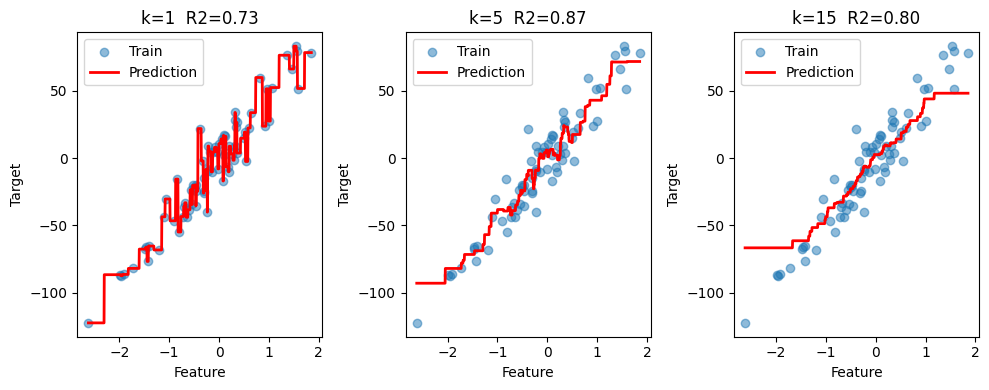

In [8]:
X_reg, y_reg = make_regression(n_features=1, noise=15, random_state=42)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, random_state=42)
plt.figure(figsize=(10, 4))
for i, k in enumerate([1, 5, 15]):
    knn_r = KNeighborsRegressor(n_neighbors=k)
    knn_r.fit(Xr_train, yr_train)
    X_plot = np.linspace(X_reg.min(), X_reg.max(), 1000).reshape(-1, 1)
    y_plot = knn_r.predict(X_plot)
    plt.subplot(1, 3, i + 1)
    plt.scatter(Xr_train, yr_train, alpha=0.5, label='Train')
    plt.plot(X_plot, y_plot, 'r-', linewidth=2, label='Prediction')
    r2 = knn_r.score(Xr_test, yr_test)
    plt.title('k={}  R2={:.2f}'.format(k, r2))
    plt.xlabel('Feature')
    plt.ylabel('Target')
    plt.legend()
plt.tight_layout()
plt.show()

## তুমি কি বুঝতে পেরেছ?1. KNN কীভাবে ভবিষ্যদ্বাণী করে?2. k-এর মান ছোট হলে কী সমস্যা হয়?3. k-এর মান বড় হলে কী সমস্যা হয়?4. KNN রিগ্রেশন আর ক্লাসিফিকেশনের মধ্যে পার্থক্য কী?

## সারসংক্ষেপ

| বিষয় | ব্যাখ্যা |
|-------|----------|
| KNN | নতুন বিন্দুর k nearest neighbor-এর ভোটে সিদ্ধান্ত নেয় |
| k | соседের সংখ্যা (ছোট k = জটিল, বড় k = সরল) |
| weights | 'uniform' বা 'distance' (কাছের соседকে বেশি গুরুত্ব) |
| n_neighbors | কতজন сосед দেখবে (ডিফল্ট 5) |